Populando

In [95]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [143]:
OUTPUT_DIR = Path('../data')

cardinali = pd.read_csv(OUTPUT_DIR / 'cardinali.csv')
roca = pd.read_csv(OUTPUT_DIR / 'roca.csv')

df = pd.concat([cardinali, roca], ignore_index=True)

print(f'cardinali: {len(cardinali)} linhas')
print(f'roca:      {len(roca)} linhas')
print(f'total:     {len(df)} linhas')
df.head(3)



cardinali: 4232 linhas
roca:      2360 linhas
total:     6592 linhas


,fonte,codigo,titulo,tipo,subtipo,finalidade,preco_locacao,preco_venda,valor_condominio,valor_iptu,...,banheiros,garagens,area_total,area_construida,area_util,area_terreno,descricao,url,latitude,longitude
0,Cardinali,237897,Valor do aluguel está incluso condômino e IPTU,Apartamento,Padrao,Locacao,"1.112,00",NaN,",",.,...,1.0,1.0,NaN,NaN,50.0,NaN,Valor do aluguel está incluso condômino e IPTU...,https://www.cardinali.com.br/alugar/Sao-Carlos...,-22.026474,-47.917273
1,Cardinali,237895,Sala comercial com ótima localização.,Comercial,Salao,Locacao,"5.556,00",NaN,1,",",...,2.0,5.0,NaN,90.0,NaN,90.0,Locação de salão comercial no bairro Vila Mari...,https://www.cardinali.com.br/alugar/Sao-Carlos...,-21.995478,-47.889818
2,Cardinali,237894,Sala comercial com ótima localização.,Comercial,Salao,Locacao,"5.556,00",NaN,1,",",...,2.0,5.0,NaN,90.0,NaN,90.0,Locação de salão comercial no bairro Vila Mari...,https://www.cardinali.com.br/alugar/Sao-Carlos...,-21.995478,-47.889818


Pre processamento

In [144]:
df.columns = df.columns.str.lower().str.strip()
colunas_texto = ["tipo", "subtipo", "finalidade", "bairro", "cidade", "estado", "fonte"]

for coluna in colunas_texto:
    if coluna in df.columns:
        df[coluna] = df[coluna].str.lower().str.strip()
        df[coluna] = df[coluna].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

if "tipo" in df.columns:
    df = df[(df["tipo"] != "comercial") & (df["tipo"] != "rural")]

if "finalidade" in df.columns:
    df = df[df["finalidade"].isin(["locacao"])]

if "tipo" in df.columns:
    mapeamento = {
        'apartamentos': 'apartamento',
        'casas': 'casa',
        'terrenos': 'terreno'
    }
    df['tipo'] = df['tipo'].replace(mapeamento)

remover = ['preco_venda', 'descricao', 'url', 'codigo', 'titulo', 'estado', 'cidade','endereco', 'finalidade', 'subtipo']

df = df.drop(remover, axis=1, errors='ignore')

colunas_financeiras = ['preco_locacao', 'valor_condominio', 'valor_iptu']
for col in colunas_financeiras:
    if col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].astype(object)
            df[col] = df[col].replace({'.': np.nan, ',': np.nan, '': np.nan, 'nan': np.nan})
            mask = df[col].apply(lambda x: isinstance(x, str))
            df.loc[mask, col] = df.loc[mask, col].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
        if col in ['valor_condominio', 'valor_iptu']:
            df[col] = df[col].fillna(0)

colunas_contagem = ['dormitorios', 'suites', 'banheiros', 'garagens']
for col in colunas_contagem:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

colunas_area = ['area_total', 'area_construida', 'area_util', 'area_terreno']
for col in colunas_area:
    if col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].astype(object)
            mask = df[col].apply(lambda x: isinstance(x, str))
            df.loc[mask, col] = df.loc[mask, col].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'area_util' in df.columns:
    if 'area_construida' in df.columns:
        df['area_util'] = df['area_util'].fillna(df['area_construida'])
    if 'area_total' in df.columns:
        df['area_util'] = df['area_util'].fillna(df['area_total'])

for col in colunas_area:
    if col in df.columns and col != 'area_util':
        df[col] = df[col].fillna(df['area_util'])

colunas_para_remover = ['area_total', 'area_construida', 'area_terreno']
df = df.drop(colunas_para_remover, axis=1, errors='ignore')

colunas_essenciais = ['preco_locacao', 'bairro', 'area_util','latitude', 'longitude']
df = df.dropna(subset=[col for col in colunas_essenciais if col in df.columns])

df = df.drop_duplicates()

print(f'cardinali: {len(df[df["fonte"] == "cardinali"])} linhas')
print(f'roca:      {len(df[df["fonte"] == "roca"])} linhas')
print(f'total:     {len(df)} linhas')

df = df.reset_index(drop=True)
df.head(300)

cardinali: 227 linhas
roca:      524 linhas
total:     751 linhas


,fonte,tipo,preco_locacao,valor_condominio,valor_iptu,bairro,dormitorios,suites,banheiros,garagens,area_util,latitude,longitude
0,cardinali,apartamento,1112.0,0.00,0.00,romeu santini,2,0,1,1,50.00,-22.026474,-47.917273
1,cardinali,apartamento,1889.0,0.00,0.00,vila lutfalla,2,0,1,1,50.00,-22.030589,-47.887940
2,cardinali,apartamento,1667.0,295.57,25.93,jardim paraiso,1,0,1,0,30.00,-22.009899,-47.902220
3,cardinali,casa,1334.0,0.00,40.00,vila marina,2,0,1,0,40.00,-21.995478,-47.889818
4,cardinali,apartamento,1778.0,344.59,90.00,jardim santa paula,2,0,1,1,48.00,-22.000347,-47.902719
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,roca,apartamento,1667.0,446.00,87.00,parque santa monica,4,0,2,1,70.00,-22.019900,-47.912580
296,roca,casa,2334.0,0.00,100.00,jardim cruzeiro do sul,3,139,3,2,165.00,-22.046070,-47.887590
297,roca,apartamento,1910.0,455.00,0.00,parque arnold schimidt,1,0,1,0,39.00,-22.000810,-47.900030
298,roca,apartamento,1889.0,369.00,54.00,centro,2,0,1,1,70.02,-22.015300,-47.895240


In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 833 entries, 0 to 832
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fonte             833 non-null    str    
 1   tipo              833 non-null    str    
 2   subtipo           833 non-null    str    
 3   preco_locacao     833 non-null    float64
 4   valor_condominio  833 non-null    float64
 5   valor_iptu        833 non-null    float64
 6   bairro            833 non-null    str    
 7   latitude          770 non-null    float64
 8   longitude         770 non-null    float64
 9   dormitorios       833 non-null    int64  
 10  suites            833 non-null    int64  
 11  banheiros         833 non-null    int64  
 12  garagens          833 non-null    int64  
 13  area_util         833 non-null    float64
dtypes: float64(6), int64(4), str(4)
memory usage: 91.2 KB


/var/folders/rh/gdcp6n5j2tjcrx8tg7_jqqn40000gn/T/ipykernel_74849/177847429.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


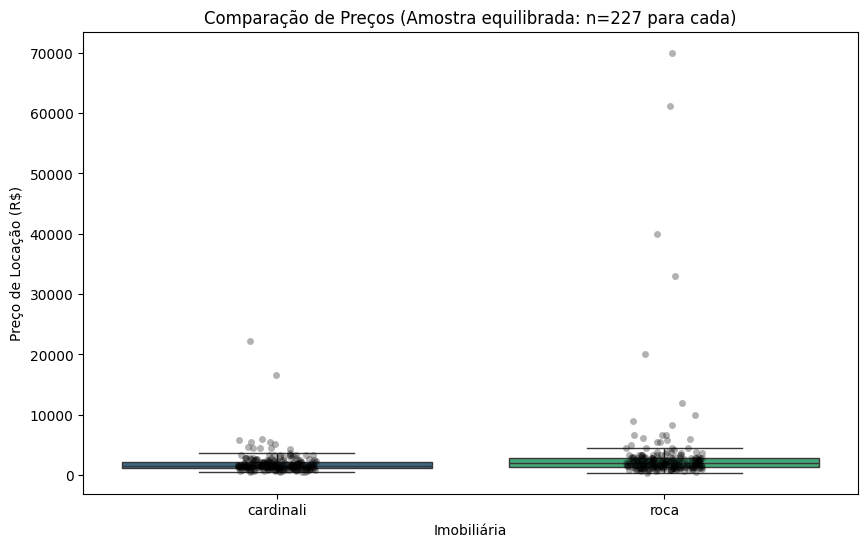

In [145]:
menor_n = df['fonte'].value_counts().min()
df_plot = df.groupby('fonte').sample(n=menor_n, random_state=42)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_plot, 
    x='fonte', 
    y='preco_locacao', 
    palette='viridis',
    showfliers=False
)

sns.stripplot(
    data=df_plot, 
    x='fonte', 
    y='preco_locacao', 
    color='black', 
    alpha=0.3, 
    jitter=True
)

plt.title(f'Comparação de Preços (Amostra equilibrada: n={menor_n} para cada)')
plt.ylabel('Preço de Locação (R$)')
plt.xlabel('Imobiliária')
plt.show()

# Distância até à USP ou UFSCar: Imóveis perto das universidades têm uma dinâmica de preço completamente diferente em São Carlos.

# Distância até ao Centro: Valoriza o imóvel.

# Distância até ao Shopping: Outro fator de valorização.

63


In [146]:
df.head(10)

,fonte,tipo,preco_locacao,valor_condominio,valor_iptu,bairro,dormitorios,suites,banheiros,garagens,area_util,latitude,longitude
0,cardinali,apartamento,1112.0,0.00,0.00,romeu santini,2,0,1,1,50.00,-22.026474,-47.917273
1,cardinali,apartamento,1889.0,0.00,0.00,vila lutfalla,2,0,1,1,50.00,-22.030589,-47.887940
2,cardinali,apartamento,1667.0,295.57,25.93,jardim paraiso,1,0,1,0,30.00,-22.009899,-47.902220
3,cardinali,casa,1334.0,0.00,40.00,vila marina,2,0,1,0,40.00,-21.995478,-47.889818
4,cardinali,apartamento,1778.0,344.59,90.00,jardim santa paula,2,0,1,1,48.00,-22.000347,-47.902719
5,cardinali,apartamento,1389.0,410.00,0.00,vila lutfalla,2,0,1,1,52.00,-22.030589,-47.887940
6,cardinali,apartamento,1334.0,300.00,50.00,recreio sao judas tadeu,2,0,1,1,45.00,-22.033950,-47.866221
7,cardinali,apartamento,1900.0,1.00,1.00,recreio sao judas tadeu,2,0,1,1,49.21,-22.033950,-47.866221
8,cardinali,casa,2334.0,1.00,95.50,centro,2,0,1,0,110.93,-22.022019,-47.892932
9,cardinali,apartamento,1889.0,420.00,70.00,recreio sao judas tadeu,2,0,1,1,58.00,-22.033950,-47.866221


In [99]:
df.iloc[0]

fonte                   cardinali
tipo                  apartamento
subtipo                    padrao
preco_locacao              1112.0
valor_condominio              0.0
valor_iptu                    0.0
bairro              romeu santini
latitude               -22.002884
longitude               -47.90085
dormitorios                     2
suites                          0
banheiros                       1
garagens                        1
area_util                    50.0
Name: 0, dtype: object

In [ ]:
# Versão A: só tabular
model.fit(X_tabular, y); r2_a = model.score(X_test, y_test)

# Versão B: tabular + 10 flags de amenidades
model.fit(X_tabular_plus_nlp, y); r2_b = model.score(X_test, y_test)

print(f'ganho: {r2_b - r2_a:.3f}')
